      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
0         2   2     3       0  
1         0

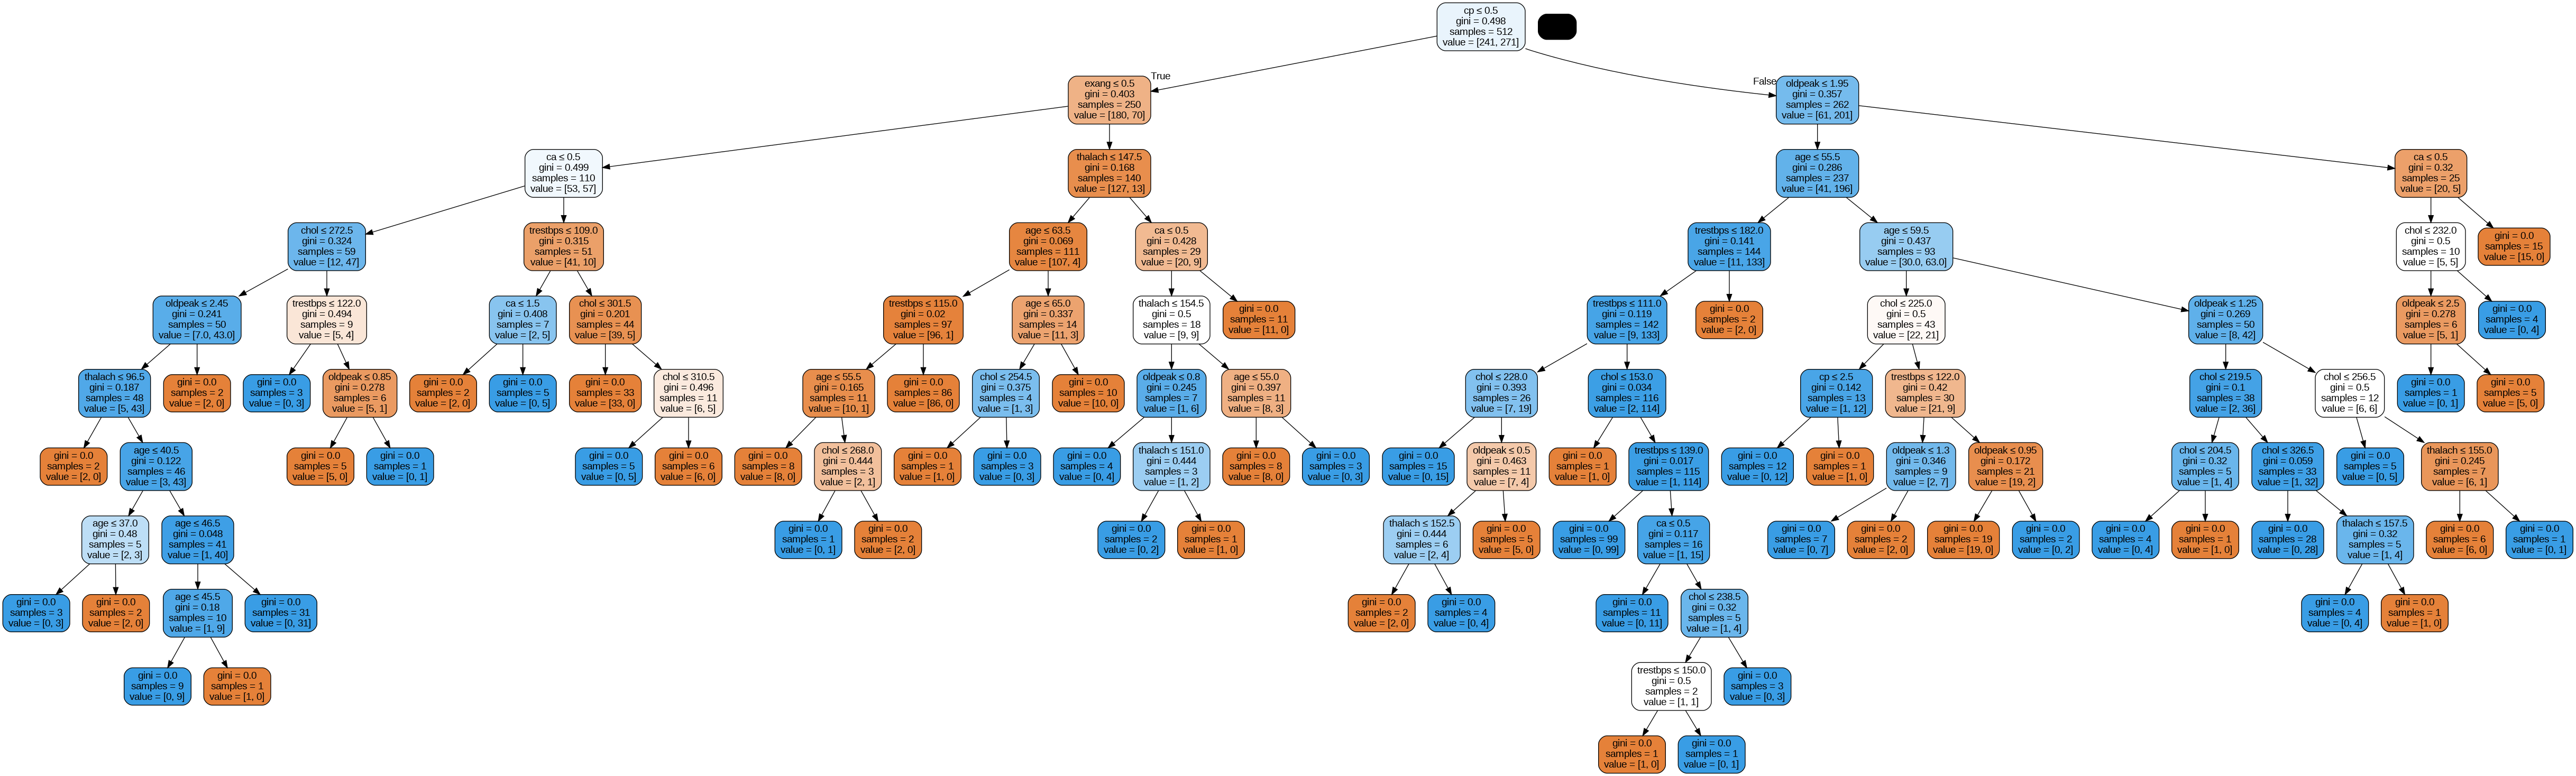

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, chi2
from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

col_names = ['age','sex','cp','trestbps','chol','fbs',
             'restecg','thalach','exang','oldpeak',
             'slope','ca','thal']

# Load dataset
ds = pd.read_csv('heart.csv',
                 encoding="ISO-8859-1")

print(ds)

# Split dataset into features and target variable
X = ds[col_names]     # Features
y = ds["target"]      # Target variable

# -----------------------------------
# Feature Selection using Chi-Square Test
# -----------------------------------

# Apply Chi-Square test
chi_selector = SelectKBest(score_func=chi2, k=8)

X_new = chi_selector.fit_transform(X, y)

# Get Chi-Square scores
feature_scores = pd.DataFrame({
    'Feature': col_names,
    'Chi_Square_Score': chi_selector.scores_
})

# Sort features based on score
feature_scores = feature_scores.sort_values(
    by='Chi_Square_Score',
    ascending=False
)

print("\nFeature Selection using Chi-Square Test")
print(feature_scores)

# Select top 8 features
selected_features = feature_scores['Feature'].head(8).tolist()

print("\nSelected Features:")
print(selected_features)

# Use selected features
X = ds[selected_features]

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=1
)

# Create Decision Tree classifier object
clf = DecisionTreeClassifier()

# Train Decision Tree classifier
clf = clf.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = clf.predict(X_test)

# Model Accuracy
print("Accuracy (%):",
      metrics.accuracy_score(y_test, y_pred) * 100)

predicted = y_pred
xtest = X_test
ytest = y_test

print(f'predicted all rows {xtest} ==== {predicted} \n Actual {ytest}.\n')

from sklearn.metrics import accuracy_score
print('Accuracy DT..................')
print(accuracy_score(predicted, ytest))

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print("confusion_matrix = ")
print(confusion_matrix(ytest, predicted))

print(classification_report(ytest, predicted))

# Decision Tree Visualization
dot_data = StringIO()

export_graphviz(
    clf,
    out_file=dot_data,
    filled=True,
    rounded=True,
    special_characters=True,
    feature_names=selected_features
)

graph = pydotplus.graph_from_dot_data(
    dot_data.getvalue()
)

Image(graph.create_png())